In [52]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers
from time import perf_counter 
import os
from keras.callbacks import ModelCheckpoint
from keras.models import load_model
from tensorflow.keras.utils import plot_model

In [53]:
## Defining batch specfications
batch_size = 100
img_height = 250
img_width = 250

In [54]:
## loading training set
training_data = tf.keras.preprocessing.image_dataset_from_directory(
    'data/train',
    seed=42,
    image_size= (img_height, img_width),
    batch_size=batch_size,
    color_mode='rgb'
)

Found 889 files belonging to 2 classes.


In [55]:
## loading validation dataset
validation_data =  tf.keras.preprocessing.image_dataset_from_directory(
    'data/val',
    seed=42,
    image_size= (img_height, img_width),
    batch_size=batch_size,
    color_mode='rgb'
)

Found 98 files belonging to 2 classes.


In [56]:
## loading testing dataset
testing_data = tf.keras.preprocessing.image_dataset_from_directory(
    'data/test',
    seed=42,
    image_size= (img_height, img_width),
    batch_size=batch_size,
    color_mode='rgb'
)

Found 100 files belonging to 2 classes.


In [57]:
testing_data

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 250, 250, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>

In [58]:
class_names = training_data.class_names
class_names

['Accident', 'Non Accident']

In [59]:
## Configuring dataset for performance
AUTOTUNE = tf.data.experimental.AUTOTUNE
training_data = training_data.cache().prefetch(buffer_size=AUTOTUNE)
testing_data = testing_data.cache().prefetch(buffer_size=AUTOTUNE)

In [60]:
## Defining Cnn
model = tf.keras.models.Sequential([
  layers.BatchNormalization(),
  layers.Conv2D(32, 3, activation='relu'), # Conv2D(f_size, filter_size, activation) # relu, sigmoid, softmax
  layers.MaxPooling2D(), # MaxPooling
  layers.Conv2D(64, 3, activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(128, 3, activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(256, 3, activation='relu'),
  layers.MaxPooling2D(),
  layers.Flatten(),
  layers.Dense(512, activation='relu'),
  layers.Dense(len(class_names), activation= 'softmax')
])

model.compile(optimizer='adam',loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [61]:
model.build((None, 250, 250, 3))
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ batch_normalization_3           │ (None, 250, 250, 3)    │            12 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 248, 248, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 124, 124, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 122, 122, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 61, 61, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 59, 59, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 29, 29, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 27, 27, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 13, 13, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 43264)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 512)            │    22,151,680 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 2)              │         1,026 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,541,134 (85.99 MB)

 Trainable params: 22,541,128 (85.99 MB)

 Non-trainable params: 6 (24.00 B)

In [62]:
plot_model(model, show_shapes=True)

You must install graphviz (see instructions at https://graphviz.gitlab.io/download/) for `plot_model` to work.


In [63]:
## lets train our CNN
checkpoint = ModelCheckpoint("model_weights.h5", monitor='val_accuracy', verbose=1, save_best_only=True, mode='max')
callbacks_list = [checkpoint]
history = model.fit(training_data, validation_data=validation_data, epochs = 20, callbacks=callbacks_list)

Epoch 1/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.5252 - loss: 2.9544
Epoch 1: val_accuracy improved from None to 0.56122, saving model to model_weights.h5



Epoch 1: finished saving model to model_weights.h5
9/9 ━━━━━━━━━━━━━━━━━━━━ 39s 3s/step - accuracy: 0.5174 - loss: 2.1151 - val_accuracy: 0.5612 - val_loss: 0.6679
Epoch 2/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6379 - loss: 0.6695
Epoch 2: val_accuracy improved from 0.56122 to 0.67347, saving model to model_weights.h5



Epoch 2: finished saving model to model_weights.h5
9/9 ━━━━━━━━━━━━━━━━━━━━ 20s 2s/step - accuracy: 0.6153 - loss: 0.6555 - val_accuracy: 0.6735 - val_loss: 0.5542
Epoch 3/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6873 - loss: 0.5896
Epoch 3: val_accuracy improved from 0.67347 to 0.72449, saving model to model_weights.h5



Epoch 3: finished saving model to model_weights.h5
9/9 ━━━━━━━━━━━━━━━━━━━━ 14s 2s/step - accuracy: 0.6952 - loss: 0.5852 - val_accuracy: 0.7245 - val_loss: 0.5236
Epoch 4/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7639 - loss: 0.5220
Epoch 4: val_accuracy did not improve from 0.72449
9/9 ━━━━━━━━━━━━━━━━━━━━ 19s 2s/step - accuracy: 0.7593 - loss: 0.5129 - val_accuracy: 0.6939 - val_loss: 0.6111
Epoch 5/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8037 - loss: 0.4617
Epoch 5: val_accuracy did not improve from 0.72449
9/9 ━━━━━━━━━━━━━━━━━━━━ 24s 3s/step - accuracy: 0.8189 - loss: 0.4369 - val_accuracy: 0.6837 - val_loss: 0.5952
Epoch 6/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8442 - loss: 0.3623
Epoch 6: val_accuracy improved from 0.72449 to 0.85714, saving model to model_weights.h5



Epoch 6: finished saving model to model_weights.h5
9/9 ━━━━━━━━━━━━━━━━━━━━ 24s 3s/step - accuracy: 0.8695 - loss: 0.3207 - val_accuracy: 0.8571 - val_loss: 0.3197
Epoch 7/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8588 - loss: 0.2917
Epoch 7: val_accuracy did not improve from 0.85714
9/9 ━━━━━━━━━━━━━━━━━━━━ 23s 3s/step - accuracy: 0.8706 - loss: 0.2888 - val_accuracy: 0.8265 - val_loss: 0.3293
Epoch 8/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9002 - loss: 0.2449
Epoch 8: val_accuracy did not improve from 0.85714
9/9 ━━━━━━━━━━━━━━━━━━━━ 23s 3s/step - accuracy: 0.9145 - loss: 0.2191 - val_accuracy: 0.8469 - val_loss: 0.5207
Epoch 9/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8885 - loss: 0.2551
Epoch 9: val_accuracy did not improve from 0.85714
9/9 ━━━━━━━━━━━━━━━━━━━━ 23s 3s/step - accuracy: 0.8875 - loss: 0.2695 - val_accuracy: 0.8265 - val_loss: 0.3656
Epoch 10/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9004 - loss: 0.2412
Epoch 10: val_accu


Epoch 10: finished saving model to model_weights.h5
9/9 ━━━━━━━━━━━━━━━━━━━━ 21s 2s/step - accuracy: 0.9325 - loss: 0.2047 - val_accuracy: 0.8878 - val_loss: 0.2784
Epoch 11/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9362 - loss: 0.1698
Epoch 11: val_accuracy did not improve from 0.88776
9/9 ━━━━━━━━━━━━━━━━━━━━ 23s 3s/step - accuracy: 0.9359 - loss: 0.1778 - val_accuracy: 0.7857 - val_loss: 0.5563
Epoch 12/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9233 - loss: 0.2075
Epoch 12: val_accuracy improved from 0.88776 to 0.90816, saving model to model_weights.h5



Epoch 12: finished saving model to model_weights.h5
9/9 ━━━━━━━━━━━━━━━━━━━━ 23s 3s/step - accuracy: 0.9381 - loss: 0.1807 - val_accuracy: 0.9082 - val_loss: 0.4134
Epoch 13/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9440 - loss: 0.1312
Epoch 13: val_accuracy did not improve from 0.90816
9/9 ━━━━━━━━━━━━━━━━━━━━ 13s 1s/step - accuracy: 0.9561 - loss: 0.1151 - val_accuracy: 0.9082 - val_loss: 0.4063
Epoch 14/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9670 - loss: 0.0949
Epoch 14: val_accuracy did not improve from 0.90816
9/9 ━━━━━━━━━━━━━━━━━━━━ 13s 1s/step - accuracy: 0.9618 - loss: 0.0974 - val_accuracy: 0.9082 - val_loss: 0.1460
Epoch 15/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9763 - loss: 0.0649
Epoch 15: val_accuracy improved from 0.90816 to 0.91837, saving model to model_weights.h5



Epoch 15: finished saving model to model_weights.h5
9/9 ━━━━━━━━━━━━━━━━━━━━ 13s 1s/step - accuracy: 0.9696 - loss: 0.0733 - val_accuracy: 0.9184 - val_loss: 0.2194
Epoch 16/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9699 - loss: 0.0703
Epoch 16: val_accuracy improved from 0.91837 to 0.93878, saving model to model_weights.h5



Epoch 16: finished saving model to model_weights.h5
9/9 ━━━━━━━━━━━━━━━━━━━━ 13s 1s/step - accuracy: 0.9663 - loss: 0.0815 - val_accuracy: 0.9388 - val_loss: 0.1674
Epoch 17/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9673 - loss: 0.0852
Epoch 17: val_accuracy did not improve from 0.93878
9/9 ━━━━━━━━━━━━━━━━━━━━ 13s 1s/step - accuracy: 0.9696 - loss: 0.0925 - val_accuracy: 0.9082 - val_loss: 0.2261
Epoch 18/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9621 - loss: 0.1040
Epoch 18: val_accuracy improved from 0.93878 to 0.97959, saving model to model_weights.h5



Epoch 18: finished saving model to model_weights.h5
9/9 ━━━━━━━━━━━━━━━━━━━━ 13s 1s/step - accuracy: 0.9595 - loss: 0.1077 - val_accuracy: 0.9796 - val_loss: 0.0862
Epoch 19/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9871 - loss: 0.0632
Epoch 19: val_accuracy did not improve from 0.97959
9/9 ━━━━━━━━━━━━━━━━━━━━ 13s 1s/step - accuracy: 0.9843 - loss: 0.0679 - val_accuracy: 0.9490 - val_loss: 0.1042
Epoch 20/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9835 - loss: 0.0474
Epoch 20: val_accuracy did not improve from 0.97959
9/9 ━━━━━━━━━━━━━━━━━━━━ 13s 1s/step - accuracy: 0.9831 - loss: 0.0425 - val_accuracy: 0.9490 - val_loss: 0.1132


In [64]:
###### serialize model structure to JSON
model_json = model.to_json()
with open("model.json", "w") as json_file:
    json_file.write(model_json)

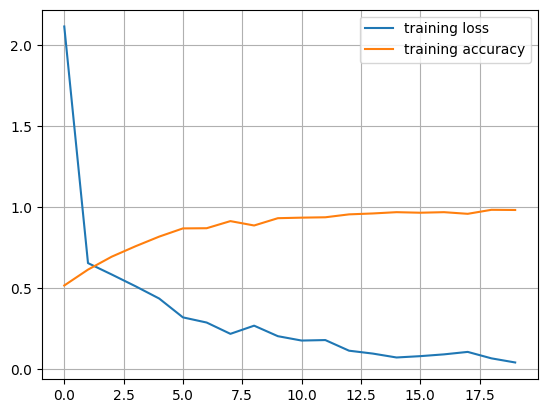

In [65]:
## stats on training data
plt.plot(history.history['loss'], label = 'training loss')
plt.plot(history.history['accuracy'], label = 'training accuracy')
plt.grid(True)
plt.legend()

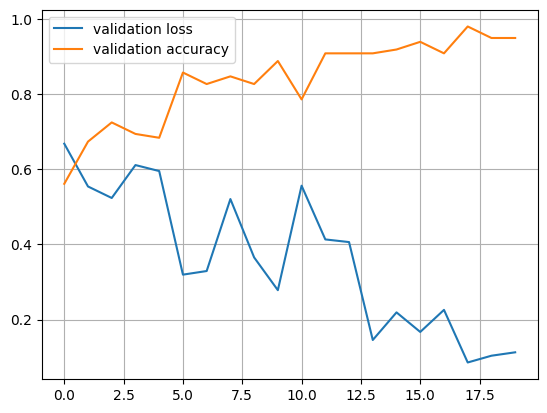

In [66]:
## stats on training data
plt.plot(history.history['val_loss'], label = 'validation loss')
plt.plot(history.history['val_accuracy'], label = 'validation accuracy')
plt.grid(True)
plt.legend()

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 105ms/step


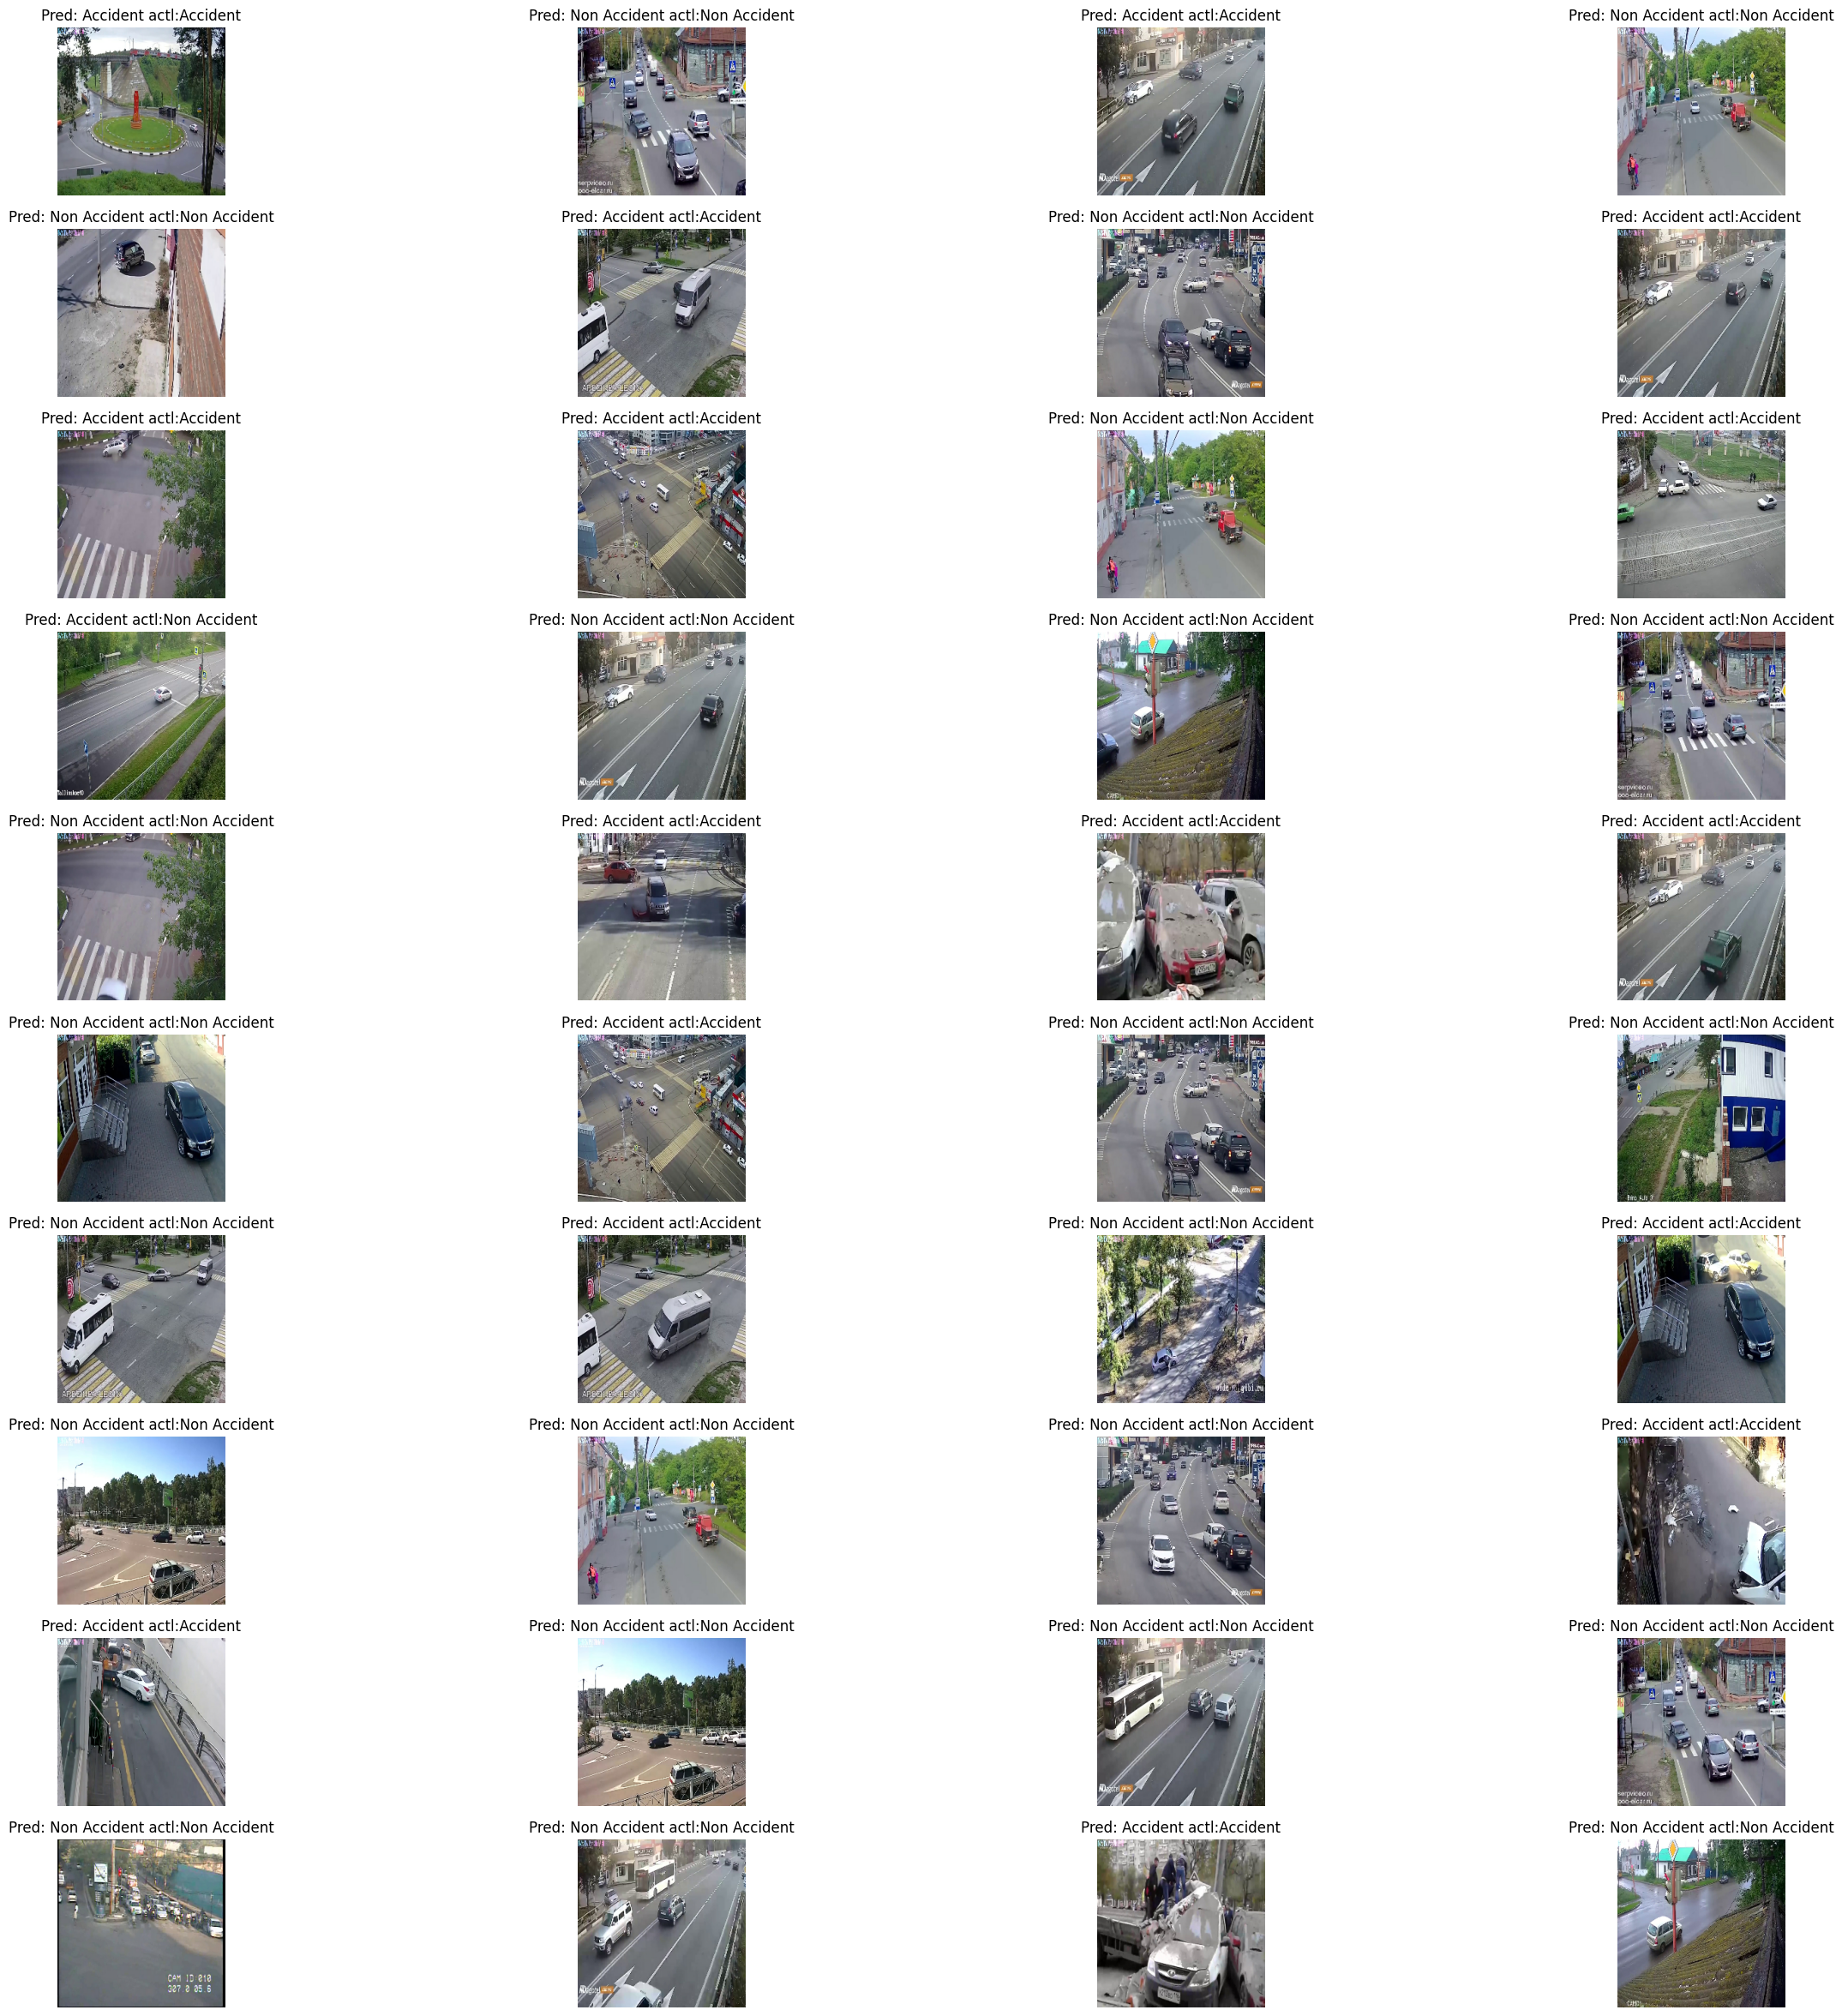

In [67]:
## lets vizualize results on testing data
AccuracyVector = []
plt.figure(figsize=(30, 30))
for images, labels in testing_data.take(1):
    predictions = model.predict(images)
    predlabel = []
    prdlbl = []
    
    for mem in predictions:
        predlabel.append(class_names[np.argmax(mem)])
        prdlbl.append(np.argmax(mem))
    
    AccuracyVector = np.array(prdlbl) == labels
    for i in range(40):
        ax = plt.subplot(10, 4, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title('Pred: '+ predlabel[i]+' actl:'+class_names[labels[i]] )
        plt.axis('off')
        plt.grid(True)

In [68]:
import shutil

# Save trained weights for use by main.py
keras_weights_path = "model_weights.weights.h5"
final_weights_path = "model_weights.h5"

model.save_weights(keras_weights_path)
shutil.copyfile(keras_weights_path, final_weights_path)

print(f"Created {final_weights_path} successfully.")

Created model_weights.h5 successfully.
